In [1]:
from utils.common import prepare_dataset, data_split, train_catboost, calculate_metrics, get_most_important_features, make_lags_dataset, calibrate_model

df = prepare_dataset('../trading_df.csv',
                    exclude_cols=['cred_limit', 'fin_cond_index', 'tax_regime', 'reg_date', 'Unnamed: 0'], 
                    year_col='year',
                    id_col='vat_num',
                    dflt_col='dflt_year',
                    drop_fin_zeroes=True,
                    drop_ones_after_ones=True)

df = make_lags_dataset(df, [1, 2])

/home/jovyan/дефолт/inference/utils/common.py:40: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df_path)


Длина датасета: 602624
Распределение таргета:
dflt_year
0    600709
1      1915
Name: count, dtype: int64
Длина датасета после добавления лаг фичей и отчистки строк с отсутствующими лаг-значениями: 480668
Распределение таргета:
target
0    478846
1      1822
Name: count, dtype: int64


In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = data_split(df, train_year_max=2022, val_year=2023, test_year=2024, target_col="target")
model = train_catboost(X_train, 
                       y_train, 
                       X_val, 
                       y_val,
                       iterations_num=10_000,
                       eval_metric="AUC",
                       learning_rate=0.01,
                       random_seed=42,
                       verbose=200,
                       early_stopping_rounds=200,
                       class_weights=None)

0:	test: 0.8053441	best: 0.8053441 (0)	total: 127ms	remaining: 21m 7s
200:	test: 0.9109681	best: 0.9109681 (200)	total: 14.6s	remaining: 11m 49s
400:	test: 0.9197608	best: 0.9197608 (400)	total: 27.7s	remaining: 11m 3s
600:	test: 0.9232206	best: 0.9232521 (596)	total: 40.5s	remaining: 10m 32s
800:	test: 0.9248847	best: 0.9248847 (800)	total: 52.3s	remaining: 10m 1s
1000:	test: 0.9259662	best: 0.9259662 (1000)	total: 1m 4s	remaining: 9m 36s
1200:	test: 0.9267765	best: 0.9267765 (1200)	total: 1m 16s	remaining: 9m 18s
1400:	test: 0.9270786	best: 0.9270832 (1391)	total: 1m 27s	remaining: 8m 58s
1600:	test: 0.9274208	best: 0.9274967 (1523)	total: 1m 39s	remaining: 8m 41s
1800:	test: 0.9279097	best: 0.9279099 (1792)	total: 1m 51s	remaining: 8m 25s
2000:	test: 0.9282826	best: 0.9282826 (2000)	total: 2m 2s	remaining: 8m 11s
2200:	test: 0.9286514	best: 0.9286922 (2141)	total: 2m 14s	remaining: 7m 56s
2400:	test: 0.9289616	best: 0.9289616 (2400)	total: 2m 26s	remaining: 7m 42s
2600:	test: 0.9295

AUC: 0.9045196055067469
Brier: 0.012861695222361242
LogLoss: 0.06221682313670393

Top 20 features by importance:
                         feature  importance
0                       2300_ebt   10.027153
1            1250_cash_and_equiv    6.543950
2                 2400_net_pofit    4.179863
3             absolute_liquidity    2.053529
4                 1210_inventory    1.995109
5      debt_to_total_liabilities    1.786094
6               days_sales_outst    1.476297
7     4221_non_curr_assets_purch    1.471087
8      total_debt_to_equity_lag2    1.442777
9   own_working_capital_adequacy    1.368036
10             net_profit_margin    1.361960
11        fa_turnover_ratio_lag2    1.272747
12             2410_inc_tax_lag1    1.165089
13           1210_inventory_lag1    1.158453
14                           roa    1.120754
15          equity_concentration    1.114700
16                  2410_inc_tax    1.066550
17             2410_inc_tax_lag2    1.016336
18          receivables_turnover

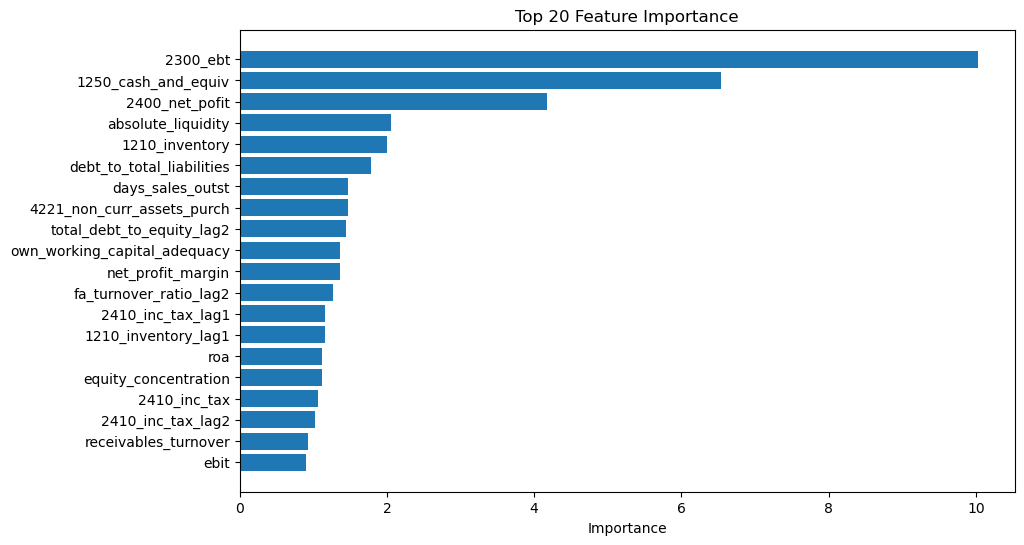

AUC: 0.9020857837448918
Brier: 0.012466884906832827
LogLoss: 0.05782795337275256


In [3]:
metrics = calculate_metrics(model, X_test, y_test)
fi_df = get_most_important_features(model, show=20)
calibrated_model = calibrate_model(model, X_val, y_val)
calibrated_metrics = calculate_metrics(calibrated_model, X_test, y_test)

In [4]:
from utils.exp_handler import save_exp

save_exp(X_train, 
         y_train, 
         X_val, 
         y_val, 
         X_test, 
         y_test,
         model,
         metrics=calibrated_metrics,
         fi_df=fi_df,
         calibrated_model=calibrated_model,
         name='big_df_lag2',
         save_data=False)

'exp/big_df_lag2'